In [5]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [9]:
whitewine = pd.read_csv('C:/Users/92323/Downloads/WineQT.csv')
whitewine = whitewine.drop('Id', axis=1)

In [11]:
#Step 1: INITIAL EDA
whitewine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [13]:
#check the number of rows/columns
print("Rows, columns: " + str(whitewine.shape))

Rows, columns: (1143, 12)


In [15]:
#checking the data
whitewine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [17]:
#check for missing values
whitewine.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [18]:
### ii.Statistical charactersitics of features and target variables  

In [19]:
#statistical charactersitics of features and target variables  
whitewine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Physiochemical Data Statistics of White Wine

| Attribute (units)                | White Wine Statistics                        |
|----------------------------------|---------------------------------------------|
| **Fixed Acidity (g/dm³)**        | Min: 4.6, Max: 15.9, Mean: 8.31             |
| **Volatile Acidity (g/dm³)**     | Min: 0.12, Max: 1.58, Mean: 0.53            |
| **Citric Acid (g/dm³)**          | Min: 0.0, Max: 1.0, Mean: 0.27             |
| **Residual Sugar (g/dm³)**       | Min: 0.9, Max: 15.5, Mean: 2.53            |
| **Chlorides (g/dm³)**            | Min: 0.012, Max: 0.611, Mean: 0.087        |
| **Free Sulfur Dioxide (mg/dm³)** | Min: 1.0, Max: 68.0, Mean: 15.62           |
| **Total Sulfur Dioxide (mg/dm³)**| Min: 6.0, Max: 289.0, Mean: 45.91          |
| **Density (g/cm³)**              | Min: 0.99007, Max: 1.00369, Mean: 0.99673  |
| **pH**                           | Min: 2.74, Max: 4.01, Mean: 3.31           |
| **Sulphates (g/dm³)**            | Min: 0.33, Max: 2.0, Mean: 0.66            |
| **Alcohol (vol.%)**              | Min: 8.4, Max: 14.9, Mean: 10.44           |
| **Quality**                      | Min: 3, Max: 8, Mean: 5.66                 |


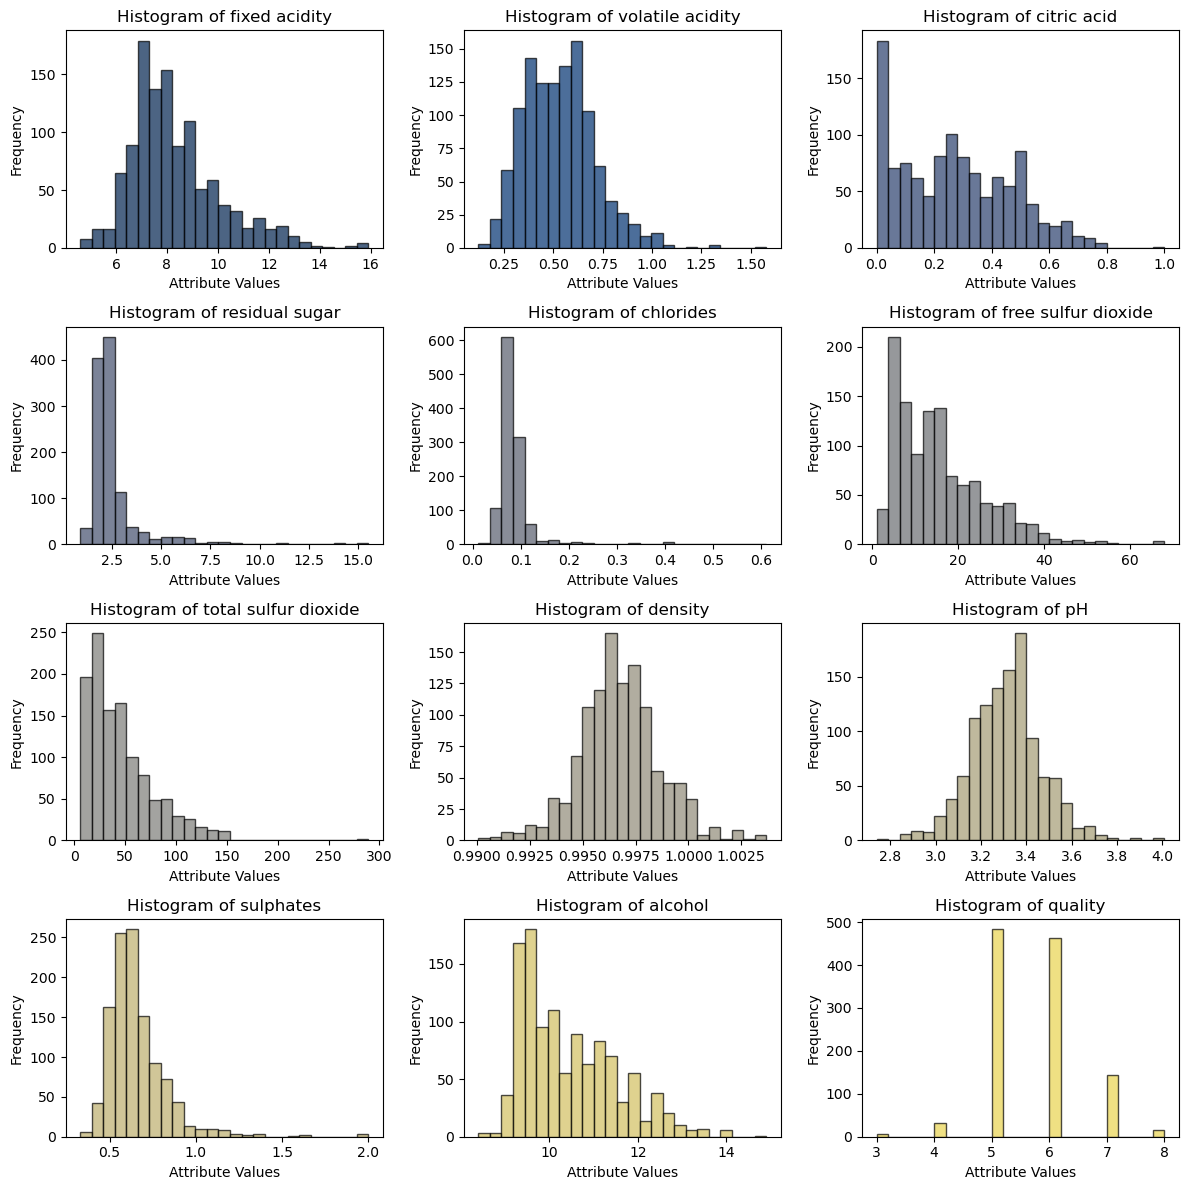

In [42]:
#In order to enhance the visualisation output:

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Set the colormap to "cividis" for better color blindness support
cmap = cm.cividis

# Dynamically calculate rows and columns based on the number of features
num_features = len(whitewine.columns)
num_cols = 3  # Number of columns in the grid
num_rows = (num_features + num_cols - 1) // num_cols  # Ceiling division for rows

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 3 * num_rows))
axes = axes.flatten()  # Flatten the axes for easier iteration

# Iterate through the columns and create individual histograms
for i, column in enumerate(whitewine.columns):
    ax = axes[i]
    # Normalize the color index to the number of columns
    color = cmap(i / num_features)
    ax.hist(whitewine[column], bins=25, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f"Histogram of {column}")
    ax.set_xlabel("Attribute Values")
    ax.set_ylabel("Frequency")

# Hide any unused subplots
for j in range(num_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Observations
---

| Property             | Observation                                                                                                         |
|----------------------|---------------------------------------------------------------------------------------------------------------------|
| Fixed Acidity        | Right-skewed distribution.                                                                   |
| Volatile Acidity     | Concentrated between 0.25 to 0.75 g/dm³, right-skewed distribution.                                                   |
| Citric Acid          | Right-skewed distribution.                                                                      |
| Residual Sugar       | Mostly < 7.5 g/dm³, right-skewed distribution with a long tail towards higher values.                                |
| Chlorides            | Mostly < 0.1 g/dm³, right-skewed distribution.                                                                      |
| Free Sulfur Dioxide  | Peak between 0 to 20 mg/dm³, right-skewed distribution.                                                            |
| Total Sulfur Dioxide | 0 to 100 mg/dm³, right-skewed distribution.                                                                       |
| Density              | Normal distribution centered around 0.9965 g/cm³.                                                           |
| pH                   | Normal distribution centered around 3.4.                                                                            |
| Sulphates            | Most values concentrated below 0.6 g/dm³, right-skewed distribution.                                                |
| Alcohol              |  Right-skewed distribution.                                                                |


### Better look at distribution of quality
---

In [ ]:
quality_data = whitewine['quality']


hist = plt.hist(quality_data, bins=25, edgecolor='k')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.title('Histogram of White Wine Quality')


plt.set_cmap('cividis')

plt.show()

### Correlation
---
From the heatmap, we can observe which attributes have a stronger positive or negative correlation with the quality of white wine.

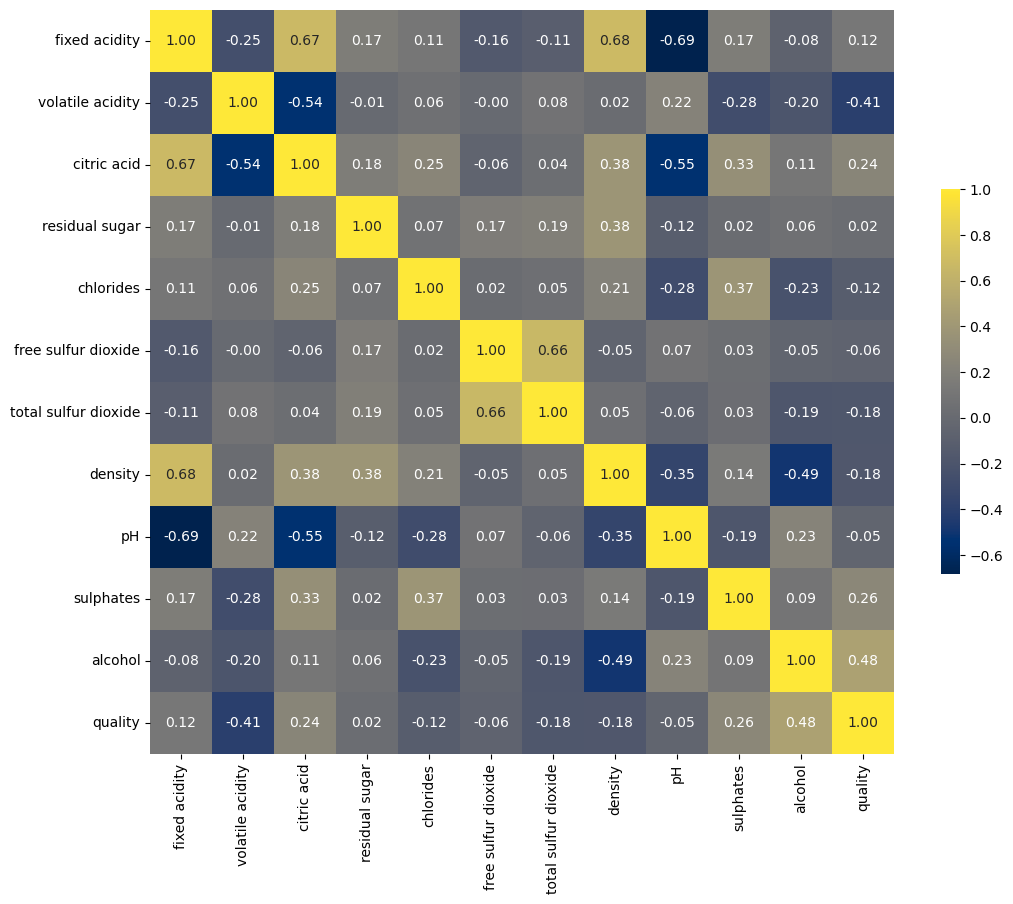

In [47]:
correlation_matrix = whitewine.corr()

# Set up the figure and plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='cividis', square=True, cbar_kws={"shrink": .5})

plt.show()

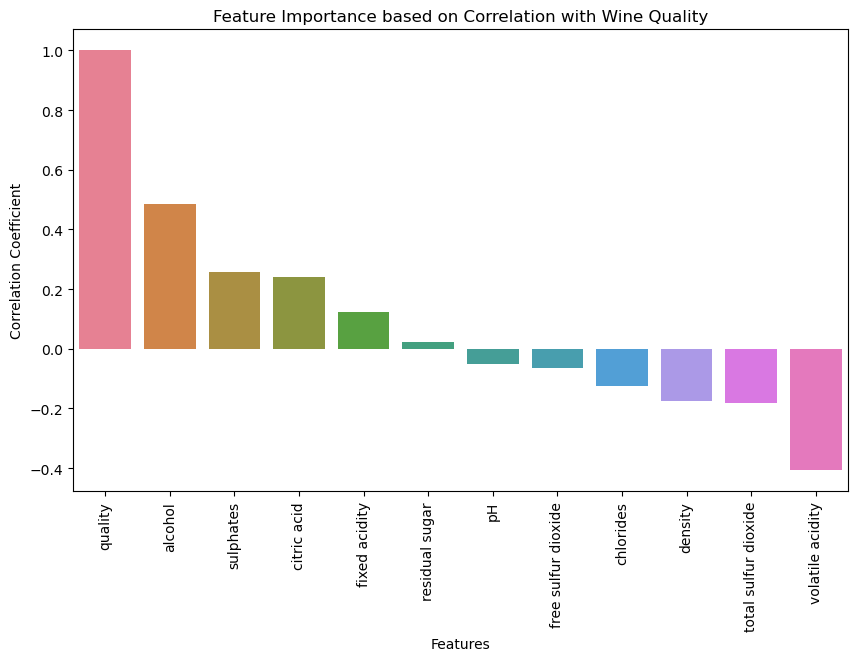

In [27]:
# Convert the colors array into a list
correlation_with_quality = whitewine.corr()['quality'].sort_values(ascending=False)
norm = plt.Normalize(correlation_with_quality.values.min(), correlation_with_quality.values.max())
colors = cmap(norm(correlation_with_quality.values))

# Visualize feature importance based on correlation with quality
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_quality.index, y=correlation_with_quality.values, hue=correlation_with_quality.index)
plt.xticks(rotation=90)
plt.title('Feature Importance based on Correlation with Wine Quality')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.show()

| Feature                  | Correlation with Quality | Insight                                                              |
|--------------------------|---------------------------|----------------------------------------------------------------------|
| Alcohol                  | Positive                  | Higher alcohol content correlates with better wine quality.          |
| Density                  | Negative                  | Lower density is associated with higher quality wines.               |
| Chlorides                | Negative                  | Higher chloride content may be linked to lower wine quality.          |
| Volatile Acidity         | Negative                  | Lower volatile acidity corresponds to higher quality ratings.         |
| Total Sulfur Dioxide     | Negative                  | Total sulfur dioxide shows a weak correlation with wine quality.      |
| pH                       | Weak                      | Slightly more acidic wines tend to have higher quality ratings.       |
| Free Sulfur Dioxide      | Weak                      | Sulfur dioxide levels have a weak impact on quality ratings.          |
| Citric Acid              | Weak                      | Citric acid has minimal direct linear relation with quality.          |
| Fixed Acidity            | Weak                      | Fixed acidity shows a very weak correlation with quality.             |
| Residual Sugar           | Very Weak                 | Residual sugar has a very weak impact on wine quality.               |


### iv. Linear Regression:

We applied a Linear Regression model to predict the quality of white wine based on selected features. The model is trained to fit the following equation:


$$
y = \beta_0 + \beta_1 \times \text{Alcohol} + \beta_2 \times \text{Sulphates} + \beta_3 \times \text{Total Sulfur Dioxide} + \beta_4 \times \text{Volatile Acidity} + \epsilon
$$

where:

- $\beta_0$ is the intercept.
- $\beta_1, \beta_2, \beta_3, \beta_4$ are the coefficients for each feature.
- $\epsilon$ is the error term.


### Data Preprocessing Steps
1. Load the dataset.
2. Select relevant features based on correlation with quality: Alcohol, Density, Chlorides, and Volatile Acidity.
3. Split the data into an 80% training set and a 20% testing set.
4. Scale the features to standardize the data.
5. Add a column of ones to the feature set to account for the intercept term.

### Code for Model Training


In [36]:
# Selecting the features based on the provided insights and extract the features and target variable
features = ['alcohol', 'sulphates', 'total sulfur dioxide', 'volatile acidity']
target = 'quality'

X = whitewine[features].values
y = whitewine[target].values

# Splitting the dataset into training and testing sets. 
#we will use a simple 80-20 split to split training and testing sets
# Feature Scaling :we will standardize features by removing the mean and scaling to unit variance
split_ratio = 0.8
split_index = int(split_ratio * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train_scaled = (X_train - mean) / std

X_test_scaled = (X_test - mean) / std

# we add a column of ones to the features to account for the intercept
# and apply linear regression using normal equation
X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])

X_test_scaled = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])


theta = np.linalg.inv(X_train_scaled.T.dot(X_train_scaled)).dot(X_train_scaled.T).dot(y_train)

# making predictions on the test set 
y_pred = X_test_scaled.dot(theta)

# Calculating R-squared and MSE
ss_total = np.sum((y_test - np.mean(y_test))**2)
ss_residual = np.sum((y_test - y_pred)**2)
r_squared = 1 - (ss_residual / ss_total)
mse = np.mean((y_test - y_pred)**2)

theta, r_squared, mse

(array([ 5.68271335,  0.33883833,  0.10521441, -0.09734053, -0.21377636]),
 0.2793213475131351,
 0.43608197785536507)

## Results

### Model Coefficients

| Coefficient      | Value        |
|------------------|--------------|
| Intercept        | 5.68271335   |
| Alcohol          | 0.33883833   |
| Sulphates        | 0.10521441   |
| Total Sulfur Dioxide        | -0.09734053  |
| Volatile Acidity | -0.21377636  |

### Performance Metrics

| Metric     | Value   |
|------------|---------|
| R-squared  | 0.27932 |
| MSE        | 0.43608 |